# 📊 Dusha — Общая статистика датасета

Анализ распределения эмоций, длительности аудио, длин текстов и транскрипций в датасете Dusha.

**Эмоции**: `angry` (0), `sad` (1), `neutral` (2), `positive` (3)

In [17]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

from my_experiments.config_utils import DATASET_PATH, EMO2LABEL, TARGET_NAMES

print(f"📂 Dataset path: {DATASET_PATH}")

📂 Dataset path: /home/natlis/PycharmProjects/dusha_new/dusha/data_processing/dataset


## 1. Загрузка данных

In [18]:
import json

DATASET_NAME = "combine_balanced_train"  # имя датасета

base_path = DATASET_PATH / 'processed_dataset_090'
manifest_path = base_path / 'aggregated_dataset' / f'{DATASET_NAME}.jsonl'

if not manifest_path.exists():
    print(f"❌ Манифест не найден: {manifest_path}")
    print("\nДоступные манифесты:")
    for f in sorted((base_path / 'aggregated_dataset').glob('*.jsonl')):
        print(f"  - {f.stem}")
else:
    records = []
    with open(manifest_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    df = pd.DataFrame(records)

    print(f"✅ Загружено {len(df)} записей из {manifest_path.name}")
    print(f"Колонки: {list(df.columns)}")
    df.head()

✅ Загружено 4205 записей из combine_balanced_train.jsonl
Колонки: ['hash_id', 'audio_path', 'duration', 'emotion', 'golden_emo', 'speaker_text', 'speaker_emo', 'source_id']


## 2. Распределение эмоций

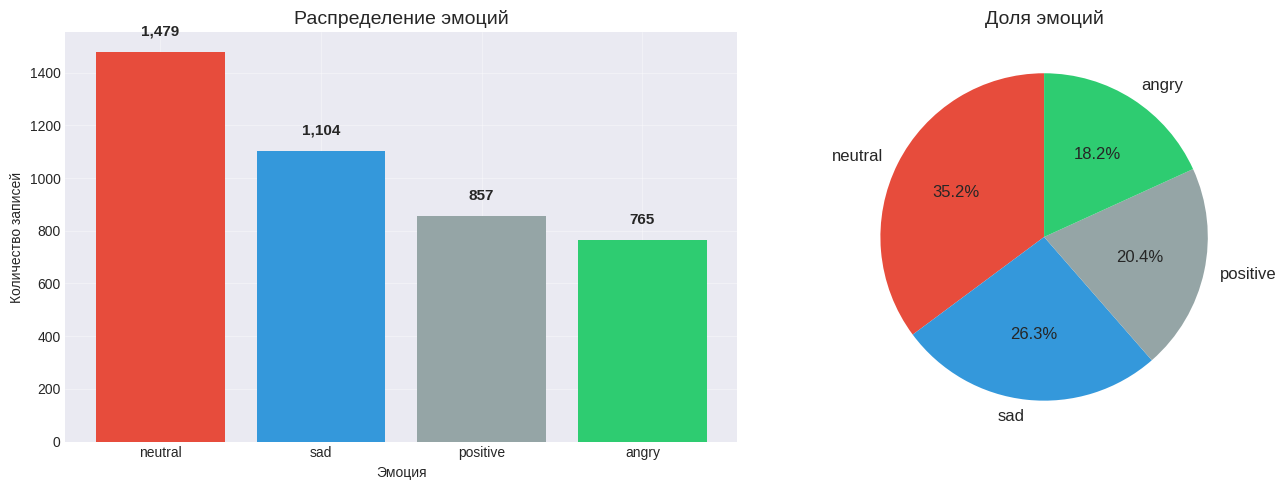


Табличное распределение:
     neutral:    1,479 (35.2%)
         sad:    1,104 (26.3%)
    positive:      857 (20.4%)
       angry:      765 (18.2%)


In [19]:
emotion_counts = df['emotion'].value_counts()
emotion_names = {0: 'angry', 1: 'sad', 2: 'neutral', 3: 'positive'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
colors = ['#e74c3c', '#3498db', '#95a5a6', '#2ecc71']
bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_title('Распределение эмоций', fontsize=14)
axes[0].set_ylabel('Количество записей')
axes[0].set_xlabel('Эмоция')
for bar, count in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Круговая диаграмма
axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Доля эмоций', fontsize=14)

plt.tight_layout()
plt.show()

print("\nТабличное распределение:")
for emotion, count in emotion_counts.items():
    print(f"  {emotion:>10}: {count:>8,} ({count / len(df) * 100:.1f}%)")

## 3. Статистика по длительности аудио

In [20]:
if 'wav_length' in df.columns:
    durations = df['wav_length']
else:
    print("Колонка wav_length не найдена, попробуем посчитать из аудио...")
    durations = None

if durations is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Общая гистограмма длительностей
    axes[0].hist(durations, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(durations.mean(), color='red', linestyle='--', linewidth=2,
                     label=f'Среднее: {durations.mean():.2f} сек')
    axes[0].axvline(durations.median(), color='orange', linestyle='--', linewidth=2,
                     label=f'Медиана: {durations.median():.2f} сек')
    axes[0].set_title('Распределение длительности аудио', fontsize=14)
    axes[0].set_xlabel('Длительность (сек)')
    axes[0].set_ylabel('Количество записей')
    axes[0].legend(fontsize=11)

    # Boxplot по эмоциям
    df.boxplot(column='wav_length', by='emotion', ax=axes[1])
    axes[1].set_title('Длительность аудио по эмоциям', fontsize=14)
    axes[1].set_xlabel('Эмоция')
    axes[1].set_ylabel('Длительность (сек)')
    plt.suptitle('')

    plt.tight_layout()
    plt.show()

    print(f"\nСтатистика длительности:")
    print(f"  Мин:     {durations.min():.2f} сек")
    print(f"  Макс:    {durations.max():.2f} сек")
    print(f"  Среднее: {durations.mean():.2f} сек")
    print(f"  Медиана: {durations.median():.2f} сек")
    print(f"  Стд:     {durations.std():.2f} сек")

    print(f"\nДлительность по эмоциям (среднее):")
    for emo in TARGET_NAMES:
        subset = df[df['emotion'] == emo]['wav_length']
        print(f"  {emo:>10}: {subset.mean():.2f} сек (±{subset.std():.2f})")

Колонка wav_length не найдена, попробуем посчитать из аудио...


## 4. Статистика по длинам текстов и транскрипций

In [21]:
# Считаем длины текстов
if 'text' in df.columns:
    df['text_len'] = df['text'].astype(str).apply(len)
    df['text_word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

if 'transcription' in df.columns:
    df['transcription_len'] = df['transcription'].astype(str).apply(len)
    df['transcription_word_count'] = df['transcription'].astype(str).apply(lambda x: len(x.split()))

text_cols = [c for c in ['text_len', 'text_word_count', 'transcription_len', 'transcription_word_count']
             if c in df.columns]

if text_cols:
    n_plots = len(text_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    titles = {
        'text_len': 'Длина текста (символы)',
        'text_word_count': 'Длина текста (слова)',
        'transcription_len': 'Длина транскрипции (символы)',
        'transcription_word_count': 'Длина транскрипции (слова)',
    }

    for ax, col in zip(axes, text_cols):
        ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_title(titles.get(col, col), fontsize=13)
        ax.set_xlabel(col)
        ax.set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

    print("\nСтатистика длин текстов:")
    for col in text_cols:
        print(f"  {titles.get(col, col):>40}: min={df[col].min()}, max={df[col].max()}, "
              f"mean={df[col].mean():.1f}, median={df[col].median():.1f}")

## 5. Соотношение спикеров и аудио по эмоциям

In [22]:
if 'speaker_id' in df.columns:
    speaker_emotion = df.groupby('emotion')['speaker_id'].nunique()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Количество уникальных спикеров по эмоциям
    speaker_emotion.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_title('Уникальные спикеры по эмоциям', fontsize=13)
    axes[0].set_ylabel('Количество спикеров')

    # Количество аудио на спикера
    speaker_counts = df.groupby('speaker_id').size()
    axes[1].hist(speaker_counts, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].set_title('Распределение: аудио на спикера', fontsize=13)
    axes[1].set_xlabel('Количество аудио')
    axes[1].set_ylabel('Количество спикеров')

    plt.tight_layout()
    plt.show()

    print(f"\nУникальных спикеров: {df['speaker_id'].nunique()}")
    print(f"Среднее аудио на спикера: {speaker_counts.mean():.1f}")
    print(f"Медиана аудио на спикера: {speaker_counts.median():.0f}")
    print(f"\nСпикеры по эмоциям:")
    for emo in TARGET_NAMES:
        n = speaker_emotion.get(emo, 0)
        print(f"  {emo:>10}: {n} спикеров")

## 6. Общая информация

In [23]:
print("=" * 50)
print("ОБЩАЯ СТАТИСТИКА ДАТАСЕТА")
print("=" * 50)
print(f"Всего записей:        {len(df):,}")
print(f"Уникальных спикеров:  {df['speaker_id'].nunique() if 'speaker_id' in df.columns else 'N/A'}")
print(f"Колонки:              {list(df.columns)}")
print(f"\nРаспределение по эмоциям:")
for emo in TARGET_NAMES:
    count = (df['emotion'] == emo).sum()
    print(f"  {emo:>10}: {count:>8,} ({count / len(df) * 100:.1f}%)")

ОБЩАЯ СТАТИСТИКА ДАТАСЕТА
Всего записей:        4,205
Уникальных спикеров:  N/A
Колонки:              ['hash_id', 'audio_path', 'duration', 'emotion', 'golden_emo', 'speaker_text', 'speaker_emo', 'source_id']

Распределение по эмоциям:
       angry:      765 (18.2%)
         sad:    1,104 (26.3%)
     neutral:    1,479 (35.2%)
    positive:      857 (20.4%)
